In [ ]:
#importing important libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
#calling the file in nyse named prices.csv
df =pd.read_csv("prices.csv", header=0)
df

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0
...,...,...,...,...,...,...,...
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0
851261,2016-12-30,ZTS,53.639999,53.529999,53.270000,53.740002,1701200.0
851262,2016-12-30 00:00:00,AIV,44.730000,45.450001,44.410000,45.590000,1380900.0


In [ ]:
#size of the dataset in 851264 rows and 7 columns
print(df.shape)

(851264, 7)


In [ ]:
# takes 20 different and unique from symbol
df.symbol.unique()[0:20]

array(['WLTW', 'A', 'AAL', 'AAP', 'AAPL', 'ABC', 'ABT', 'ACN', 'ADBE',
       'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET',
       'AFL', 'AGN'], dtype=object)

In [ ]:
# finind the length of column named symbol
print(len(df.symbol.values))

851264


In [ ]:
#gives the details of each columns of the dataset like mean, max etc
df.describe()

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [ ]:
#checking whether their is any null value in the dataset
# .sum() will give the total no. of null value column vise
df.isnull().sum()

,0
date,0
symbol,0
open,0
close,0
low,0
high,0
volume,0


In [ ]:
# taking all the unique or one time value in the date column
df.date.unique()

array(['2016-01-05 00:00:00', '2016-01-06 00:00:00',
       '2016-01-07 00:00:00', ..., '2016-12-28', '2016-12-29',
       '2016-12-30'], dtype=object)

In [ ]:
#calling the file in nyse named securities.csv
comp_info = pd.read_csv('securities.csv')
comp_info

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",2015-08-31,718877
...,...,...,...,...,...,...,...,...
500,YHOO,Yahoo Inc.,reports,Information Technology,Internet Software & Services,"Sunnyvale, California",NaN,1011006
501,YUM,Yum! Brands Inc,reports,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061
502,ZBH,Zimmer Biomet Holdings,reports,Health Care,Health Care Equipment,"Warsaw, Indiana",NaN,1136869
503,ZION,Zions Bancorp,reports,Financials,Regional Banks,"Salt Lake City, Utah",NaN,109380


In [ ]:
# taking total no. of unique values in column Ticket symbol
comp_info["Ticker symbol"].nunique()

505

In [ ]:
# for locating specific data here.... in security column of string that starts with "Face"
comp_info.loc[comp_info.Security.str.startswith('Face') , :]

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
181,FB,Facebook,reports,Information Technology,Internet Software & Services,"Menlo Park, California",2013-12-23,1326801


In [ ]:
# here we locate Ticker symbol of company with security like Yahoo, Xerox, Adobe etc
# then taking their no. of times entry and thier "Ticker symbol"
comp_plot = comp_info.loc[(comp_info["Security"] == 'Yahoo Inc.') | (comp_info["Security"] == 'Xerox Corp.') | (comp_info["Security"] == 'Adobe Systems Inc')
              | (comp_info["Security"] == 'Microsoft Corp.') | (comp_info["Security"] == 'Adobe Systems Inc')
              | (comp_info["Security"] == 'Facebook') | (comp_info["Security"] == 'Goldman Sachs Group') , ["Ticker symbol"] ]["Ticker symbol"]
print(comp_plot)

6      ADBE
181      FB
212      GS
306    MSFT
496     XRX
500    YHOO
Name: Ticker symbol, dtype: object


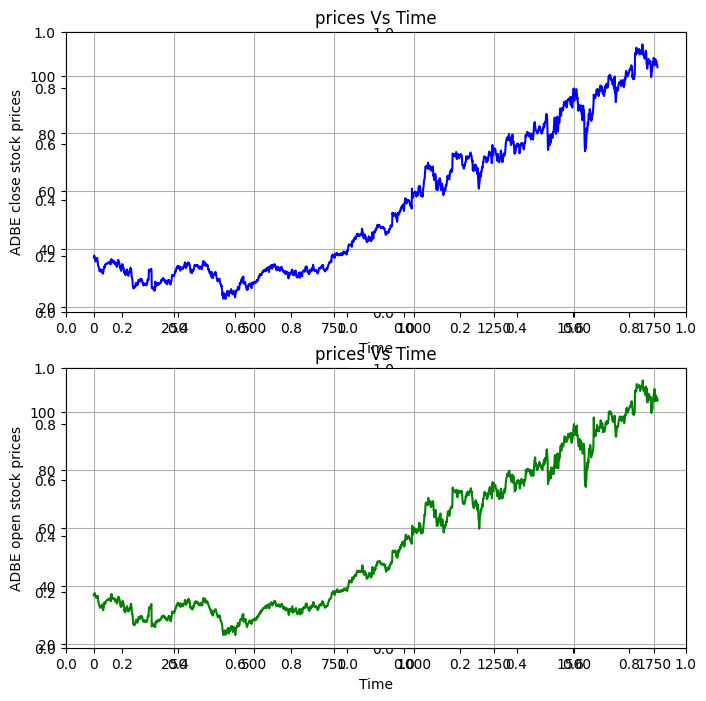

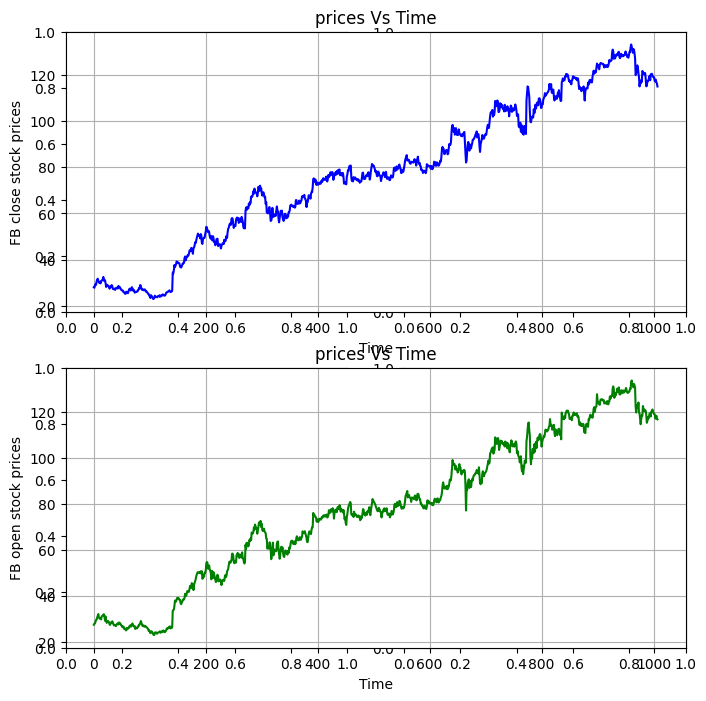

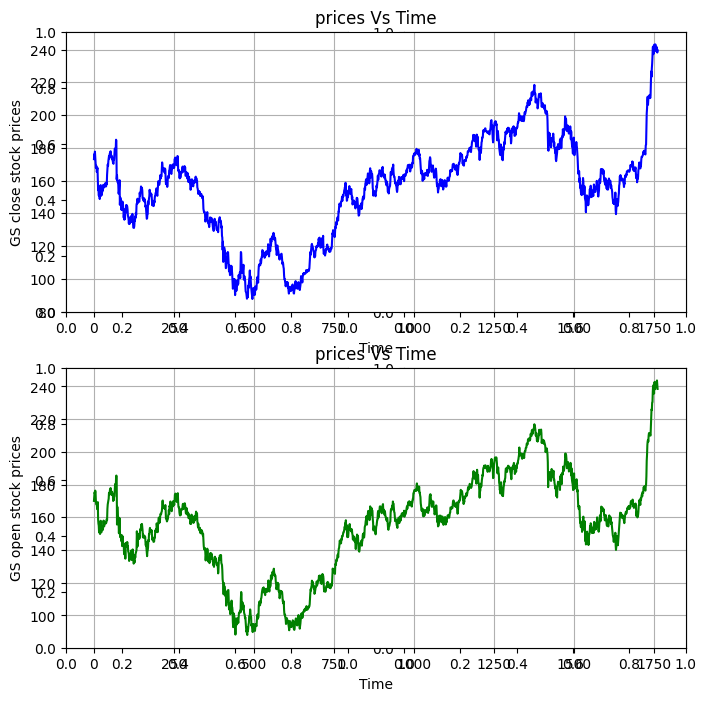

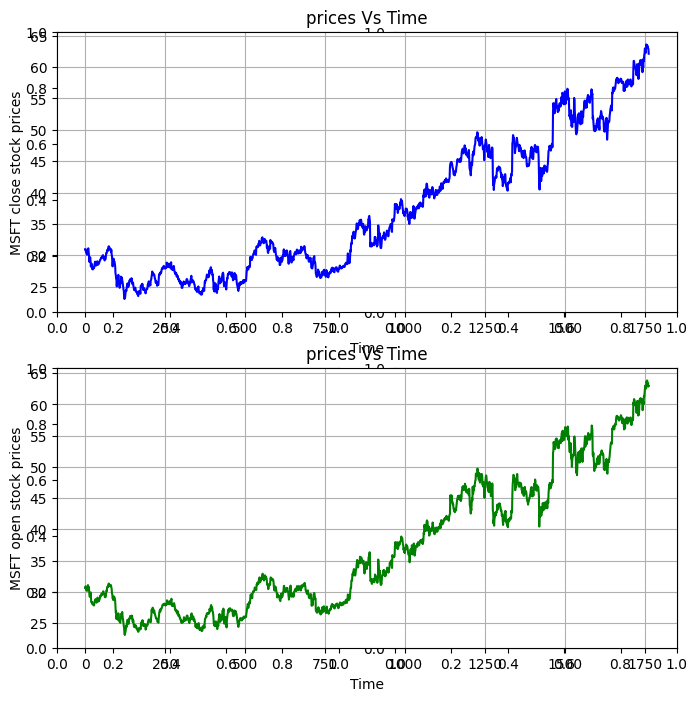

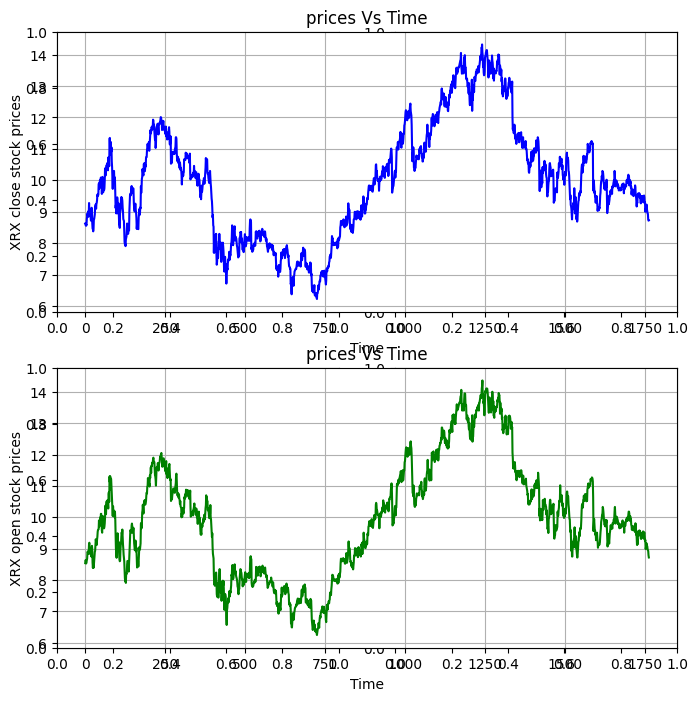

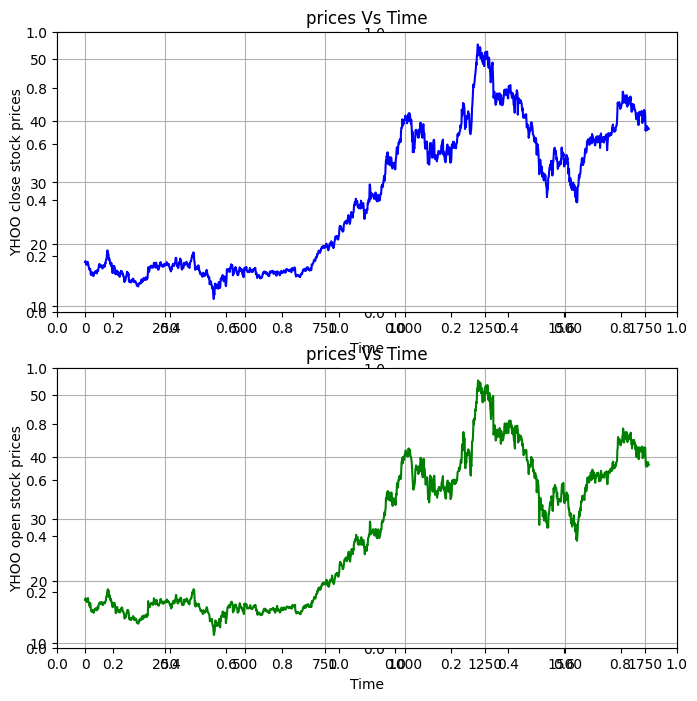

In [ ]:
def plotter(code):

    global closing_stock ,opening_stock

    f, axs = plt.subplots(2,2,figsize=(8,8))

    plt.subplot(212)

    company = df[df['symbol']==code]

    company = company.open.values.astype('float32')

    company = company.reshape(-1, 1)

    opening_stock = company


    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel(code + " open stock prices")
    plt.title('prices Vs Time')
    plt.plot(company , 'g')


    plt.subplot(211)

    company_close = df[df['symbol']==code]

    company_close = company_close.close.values.astype('float32')

    company_close = company_close.reshape(-1, 1)

    closing_stock = company_close


    plt.xlabel('Time')
    plt.ylabel(code + " close stock prices")
    plt.title('prices Vs Time')
    plt.grid(True)
    plt.plot(company_close , 'b')
    plt.show()

# calling the graphs through the function
for i in comp_plot:
    plotter(i)

**Lets take a single stock as a sample to forecast further stock prices.**

In [ ]:
#taking the values of closing_stock in a single list
closing_stock[:,0]

array([17.1 , 17.23, 17.17, ..., 38.73, 38.64, 38.67], dtype=float32)

In [ ]:
#taking the values of closing_stock in a single list called stocks
stocks = closing_stock[: , 0]
print(stocks)
#reshaping the stocks in 1D array form
stocks = stocks.reshape(len(stocks) , 1)

[17.1  17.23 17.17 ... 38.73 38.64 38.67]


**Feature scaling the vector for better model performance.**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1)) #scaling features between 0 and 1
stocks = scaler.fit_transform(stocks) # it will start learning algo and then provide scaled and dimension reduced output

In [ ]:
train = int(len(stocks) * 0.80) #creating sizes of train and taking 80% percentage of the part
test = len(stocks) - train #creating sizes of test as total minus train

In [ ]:
#sizes of train and test
print(train , test)

1409 353


In [ ]:
#divinding the values of stocks data to train from 0 to 1409 i.e 80% data
train = stocks[0:train]
print(train)

[[0.14559111]
 [0.14874032]
 [0.14728683]
 ...
 [0.63372093]
 [0.6145833 ]
 [0.6196705 ]]


In [ ]:
#divinding the values of stocks data to test from train ending to stock data ending i.e rest 20% data
test = stocks[len(train) : ]

In [ ]:
#reshaping train data in 1D array form
train = train.reshape(len(train) , 1)
#reshaping test data in 1D array form
test = test.reshape(len(test) , 1)

In [ ]:
#new train and test array shape
print(train.shape , test.shape)

(1409, 1) (353, 1)


In [ ]:
#creating function to create trainX,testX and target(trainY, testY)
def process_data(data , n_features):
    dataX, dataY = [], []
    for i in range(len(data)-n_features-1):

        a = data[i:(i+n_features), 0]

        dataX.append(a)

        dataY.append(data[i + n_features, 0])

    return np.array(dataX), np.array(dataY)

#so the stucture of trainX and trainY is somehow like this
# trainX=[[i1 , i2,...., i n_features ]] and trainY=[i + n_features]
# trainY will show the future value of trainX values

In [ ]:
n_features = 2

trainX, trainY = process_data(train, n_features)

testX, testY = process_data(test, n_features)

In [ ]:
# printing the structure of train X,Y and test X,Y
print(trainX.shape , trainY.shape , testX.shape , testY.shape)

(1406, 2) (1406,) (350, 2) (350,)


In [ ]:
# reshaping trainX and testX to use in deeplearning model
trainX = trainX.reshape(trainX.shape[0] , 1 ,trainX.shape[1])
testX = testX.reshape(testX.shape[0] , 1 ,testX.shape[1])

In [ ]:
import math
from keras.models import Sequential
from keras.layers import Dense , BatchNormalization , Dropout , Activation # types of layers
from keras.layers import LSTM , GRU
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.optimizers import Adam , SGD , RMSprop

In [ ]:
# creating model for training data using sequential to give series wise output between layers
model = Sequential()

model.add(GRU(256 , input_shape = (1 , n_features) , return_sequences=True))

model.add(Dropout(0.4))

model.add(LSTM(256))

model.add(Dropout(0.4))

model.add(Dense(64 ,  activation = 'relu'))
model.add(Dense(1))

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 256)         │       199,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 741,505 (2.83 MB)

 Trainable params: 741,505 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# selecting the loss measurement metrics and optimizer for our model , to find out mean square error
model.compile(loss='mean_squared_error', optimizer=Adam() , metrics = ['mean_squared_error'])

In [ ]:
# fitting the data i.e training the trainX, to relate to trainY
history = model.fit(trainX, trainY, epochs=100 , batch_size = 128 ,
          callbacks = [ ] , validation_data = (testX,testY))
#callbacks are proper

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.1011 - mean_squared_error: 0.1011 - val_loss: 0.0018 - val_mean_squared_error: 0.0018
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0217 - mean_squared_error: 0.0217 - val_loss: 0.0187 - val_mean_squared_error: 0.0187
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 7.5893e-04 - val_mean_squared_error: 7.5893e-04
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0036 - mean_squared_error: 0.0036 - val_loss: 0.0032 - val_mean_squared_error: 0.0032
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0029 - mean_squared_error: 0.0029 - val_loss: 0.0016 - val_mean_squared_error: 0.0016
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0023 - mean_squared_error: 0.0023 - val_loss: 0.0023 - val_mean_squared_error: 0.0023
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0017 - mean_squared_error: 0.0017 - val_lo

In [ ]:
#predicting the value for testX
pred = model.predict(testX)

pred = scaler.inverse_transform(pred)

pred[:10]
# taking pred from 1 to 10

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


array([[36.180374],
       [34.800262],
       [35.303932],
       [35.951965],
       [35.951664],
       [35.632492],
       [35.169823],
       [34.278976],
       [33.148758],
       [31.680798]], dtype=float32)

In [ ]:
# reshaping testY in single array
testY = testY.reshape(testY.shape[0] , 1)

testY = scaler.inverse_transform(testY)

testY[:10]

array([[34.49    ],
       [35.93    ],
       [36.24    ],
       [36.1     ],
       [35.69    ],
       [35.19    ],
       [34.1     ],
       [32.93    ],
       [31.31    ],
       [31.739998]], dtype=float32)

Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices


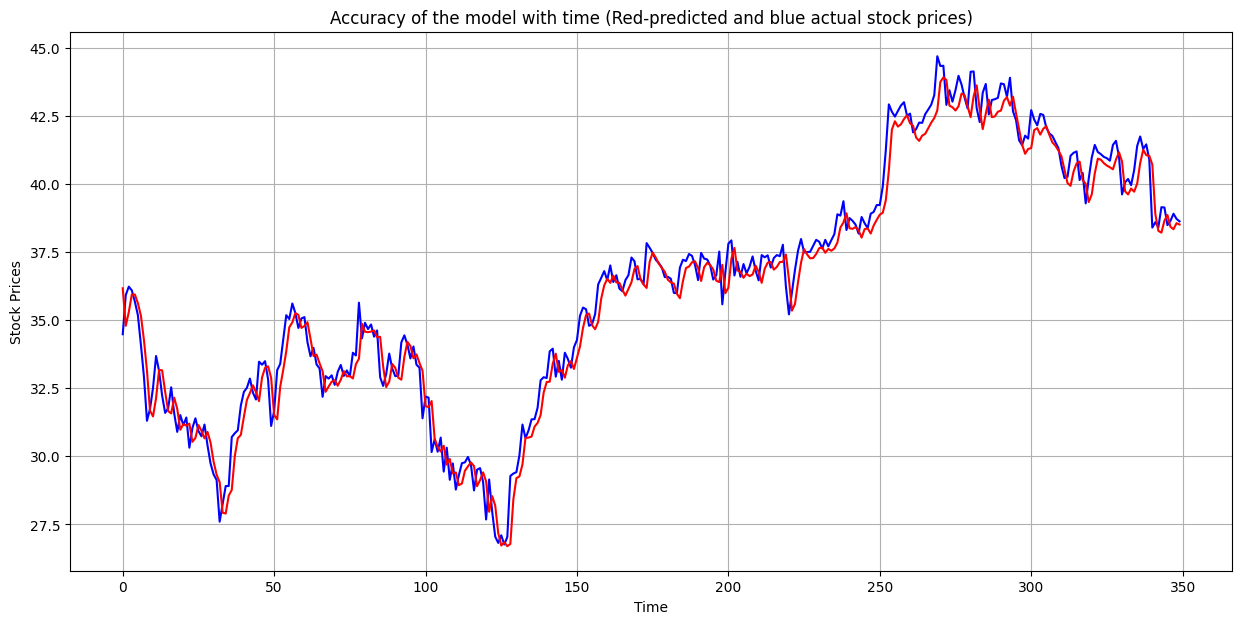

In [ ]:
# ploting the graph of stock prices with time
print("Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices")
plt.rcParams["figure.figsize"] = (15,7)

plt.plot(testY , 'b')

plt.plot(pred , 'r')

plt.xlabel('Time')

plt.ylabel('Stock Prices')

plt.title('Accuracy of the model with time (Red-predicted and blue actual stock prices)')

plt.grid(True)

plt.show()

In [ ]:
model.save("stock_prediction_gru_lstm.keras")

In [ ]:
import pandas as pd

df = pd.read_csv("MSFT.csv")
print(df.head())
print(df.columns)

         Date       Low      Open      Volume      High     Close  \
0  13-03-1986  0.088542  0.088542  1031788800  0.101563  0.097222   
1  14-03-1986  0.097222  0.097222   308160000  0.102431  0.100694   
2  17-03-1986  0.100694  0.100694   133171200  0.103299  0.102431   
3  18-03-1986  0.098958  0.102431    67766400  0.103299  0.099826   
4  19-03-1986  0.097222  0.099826    47894400  0.100694  0.098090   

   Adjusted Close  
0        0.060809  
1        0.062980  
2        0.064067  
3        0.062437  
4        0.061351  
Index(['Date', 'Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close'], dtype='object')


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("stock_prediction_gru_lstm.keras")

print(model.input_shape)

(None, 1, 2)


**Testing the model on Microsoft stock:**

Model Loaded Successfully!
Input Shape: (None, 1, 2)

Dataset Shape: (9264, 7)

Columns:
Index(['Date', 'Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close'], dtype='object')

X_test Shape: (9262, 1, 2)
290/290 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

================ RESULTS ================
MSE  : 31.09997751526697
MAE  : 4.148670805196247
RMSE : 5.5767353814993745
R²   : 0.9929781962056698


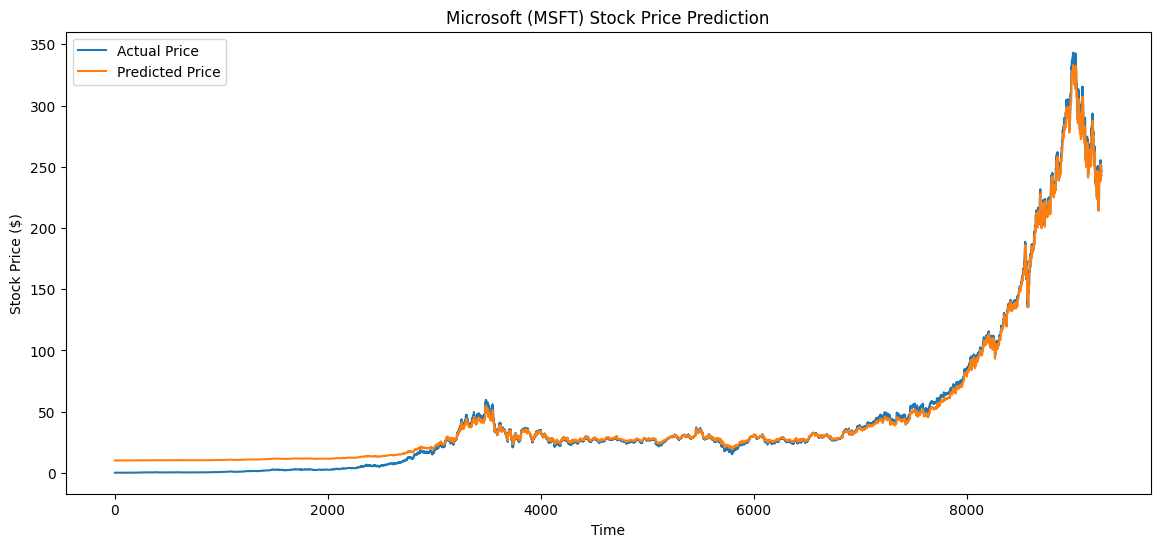


Predictions saved as:
MSFT_Predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = load_model("stock_prediction_gru_lstm.keras")

print("Model Loaded Successfully!")
print("Input Shape:", model.input_shape)


df = pd.read_csv("MSFT.csv")

print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

close_prices = df['Close'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_prices)

X_test = []
y_test = []

for i in range(2, len(scaled_data)):

    X_test.append([
        scaled_data[i-2,0],
        scaled_data[i-1,0]
    ])

    y_test.append(
        scaled_data[i,0]
    )

X_test = np.array(X_test)
y_test = np.array(y_test)


X_test = X_test.reshape(
    X_test.shape[0],
    1,
    2
)

print("\nX_test Shape:", X_test.shape)

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)


mse = mean_squared_error(actual_prices, predictions)

mae = mean_absolute_error(actual_prices, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(actual_prices, predictions)

print("\n================ RESULTS ================")

print("MSE  :", mse)
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Microsoft (MSFT) Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price ($)")
plt.legend()

plt.show()

results = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predictions.flatten()
})

results.to_csv(
    "MSFT_Predictions.csv",
    index=False
)

print("\nPredictions saved as:")
print("MSFT_Predictions.csv")